<a href="https://colab.research.google.com/github/Saritha-batch1/Multi-Model-AI-Agent/blob/Deekshitha-max-patch-1/multimodel_AI_on_HD_Deekshitha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Design and Implementation of a Mutimodel AI Agent for Automated Health Diagnosis

My view on this Project~
In this Project my goal is to build a small data Processing Pipeline that can identify,extract,validate and Standardize medical parameters from raw  data sets.
Real world medical data is often incomplete and inconsistently formatted,so we have to clean the data set and keep in structured form that is used for future analysis

working on Data gathering: I collected dataset(kidney Disease dataset) from kaggle.This dataset contain multiple clinical Parameters such as  hemoglobin,redblood cells and other measurements related to kidney health

Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/kidney_disease.csv")
display(df.head())

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


cleaning Data

Parameter Identification and Extraction:
Many of the Parameters in the raw data set were inconsistent.so I normalized the column names and Extract the key parameters that would be used for diagnostics.I also identified whether each parameter was numerical or categorical

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


Identify key medical parameters
 Extract into a separate DataFrame

In [ ]:
# list of important medical parameters present in the kidney dataset
important_cols = [
    "age","bp","bgr","bu","sc","sod","pot","hemo","pcv",
    "wc","rc","htn","dm","cad","appet","pe","ane"
]

extracted = df[important_cols]
extracted.head()


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no
1,7.0,50.0,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no
2,62.0,80.0,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no


3.Data Validation and Standardization:The raw dataset contained missing values, outliers, inconsistent spellings, and mixed data types. To make the datausable, I validated:
Data type correctness
Missing or blank values
Invalid symbols
Value ranges for numerical features
Unexpected categories in categorical features

In [ ]:
print("Missing values in each column:\n")
print(extracted.isnull().sum())


Missing values in each column:

age        9
bp        12
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       70
wc       105
rc       130
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
dtype: int64


converting into Numeric Data

In [ ]:
num_cols = ["age","bp","bgr","bu","sc","sod","pot","hemo","pcv","wc","rc"]

# convert non-numerical values to NaN
for col in num_cols:
    extracted[col] = pd.to_numeric(extracted[col], errors="coerce")


/tmp/ipython-input-396435442.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extracted[col] = pd.to_numeric(extracted[col], errors="coerce")


Fill missing numeric values

In [ ]:
for col in num_cols:
    extracted[col] = extracted[col].fillna(extracted[col].median())


/tmp/ipython-input-1581286923.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extracted[col] = extracted[col].fillna(extracted[col].median())


Handle categorical columns

In [ ]:
cat_cols = ["htn","dm","cad","appet","pe","ane"]

for col in cat_cols:
    extracted[col] = extracted[col].fillna(extracted[col].mode()[0])


/tmp/ipython-input-3221403211.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extracted[col] = extracted[col].fillna(extracted[col].mode()[0])


Data Standardization and cleaning: To prepare clean Data set ready for analysis-Replaced missing numeric values with median values-Replaced missing categorical values with mode-converting numerical values from integer to float-Standardize column names by using lower case letters,unserscores,and removing extraspaces

Standardize categorical values

In [ ]:
for col in cat_cols:
    extracted[col] = extracted[col].astype(str).str.lower()
    extracted[col] = extracted[col].replace({
        "yes":1, "y":1, "present":1,
        "no":0, "n":0, "absent":0
    })


/tmp/ipython-input-1316466620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extracted[col] = extracted[col].astype(str).str.lower()
/tmp/ipython-input-1316466620.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extracted[col] = extracted[col].replace({
/tmp/ipython-input-1316466620.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

Standardized Dataset

In [ ]:
print("Final cleaned dataset:")
extracted.head()


Final cleaned dataset:


,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,121.0,36.0,1.2,138.0,4.4,15.4,44.0,7800.0,5.2,1,1,0,good,0,0
1,7.0,50.0,121.0,18.0,0.8,138.0,4.4,11.3,38.0,6000.0,4.8,0,0,0,good,0,0
2,62.0,80.0,423.0,53.0,1.8,138.0,4.4,9.6,31.0,7500.0,4.8,0,1,0,poor,0,1
3,48.0,70.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,1,0,0,poor,1,1
4,51.0,80.0,106.0,26.0,1.4,138.0,4.4,11.6,35.0,7300.0,4.6,0,0,0,good,0,0


In [ ]:
df.columns



Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [ ]:
print(list(df.columns))


['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns


Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [ ]:
df.dtypes


,0
id,int64
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object


Text Processing

In [ ]:

df["appet"] = df["appet"].str.lower().str.strip()
df["appet"].value_counts()


,count
appet,
good,317
poor,82


In [ ]:
df["appet_encoded"] = df["appet"].map({
    "good": 1,
    "poor": 0
})


In [ ]:
binary_columns = ["htn", "dm", "cad", "pe", "ane"]

for col in binary_columns:
    print(f"{col} value counts:")
    print(df[col].value_counts())
    print("-"*30)


htn value counts:
htn
no     251
yes    147
Name: count, dtype: int64
------------------------------
dm value counts:
dm
no       258
yes      134
\tno       3
\tyes      2
 yes       1
Name: count, dtype: int64
------------------------------
cad value counts:
cad
no      362
yes      34
\tno      2
Name: count, dtype: int64
------------------------------
pe value counts:
pe
no     323
yes     76
Name: count, dtype: int64
------------------------------
ane value counts:
ane
no     339
yes     60
Name: count, dtype: int64
------------------------------


<Axes: title={'center': 'Appetite Distribution'}, xlabel='appet'>

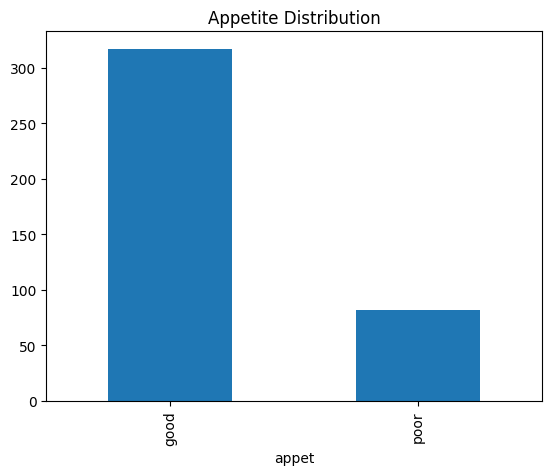

In [ ]:
df["appet"].value_counts().plot(kind="bar", title="Appetite Distribution")


In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])



In [ ]:
df.describe()


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,appet_encoded
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,399.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.794486
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,0.404584
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,1.000000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,1.000000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


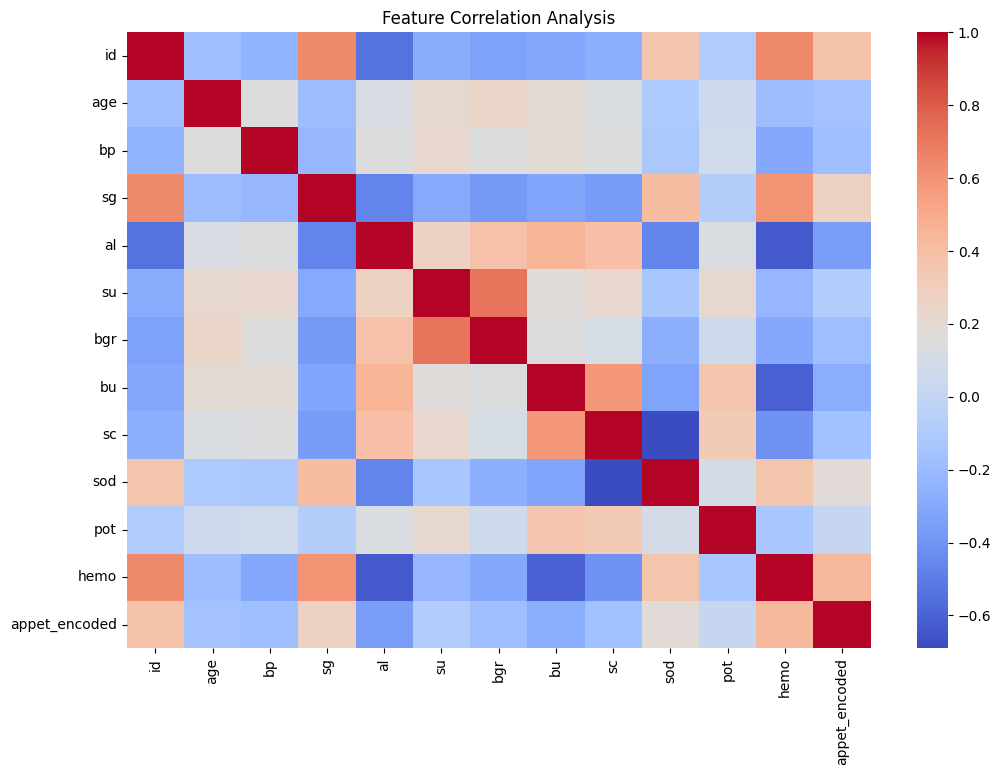

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Analysis")
plt.show()


In [ ]:
df.groupby("ane")["hemo"].mean()


,hemo
ane,
no,13.257877
yes,8.610909


In [ ]:
def row_to_text(row):
    return (
        f"Age {row['age']} with blood pressure {row['bp']}, "
        f"blood glucose {row['bgr']}, creatinine {row['sc']}, "
        f"hemoglobin {row['hemo']}, appetite {row['appet']}."
    )

df["text_representation"] = df.apply(row_to_text, axis=1)
df["text_representation"].head()


,text_representation
0,"Age 48.0 with blood pressure 80.0, blood gluco..."
1,"Age 7.0 with blood pressure 50.0, blood glucos..."
2,"Age 62.0 with blood pressure 80.0, blood gluco..."
3,"Age 48.0 with blood pressure 70.0, blood gluco..."
4,"Age 51.0 with blood pressure 80.0, blood gluco..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(df["text_representation"])

tfidf.shape


(400, 219)

Model-2: Pattern Recognition & Basic Risk Scoring

In [67]:
THRESHOLDS = {
    "sc_high": 1.5,        # serum creatinine
    "bu_high": 40,         # blood urea
    "hemo_low_male": 13,
    "hemo_low_female": 12,
    "bp_high": 140,
    "bgr_high": 140,
    "pcv_low": 36
}


In [68]:
def kidney_risk(row):
    if row["sc"] > THRESHOLDS["sc_high"] and row["bu"] > THRESHOLDS["bu_high"]:
        return 2   # High risk
    elif row["sc"] > THRESHOLDS["sc_high"]:
        return 1   # Moderate risk
    else:
        return 0   # Low risk

df["kidney_risk"] = df.apply(kidney_risk, axis=1)


In [70]:
numeric_columns = [
    "age","bp","bgr","bu","sc","sod","pot",
    "hemo","pcv","wc","rc"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [71]:
def anemia_risk(row):
    if row["hemo"] < THRESHOLDS["hemo_low_female"] and row["pcv"] < THRESHOLDS["pcv_low"]:
        return 2
    elif row["hemo"] < THRESHOLDS["hemo_low_female"]:
        return 1
    else:
        return 0

df["anemia_risk"] = df.apply(anemia_risk, axis=1)


In [72]:
def metabolic_risk(row):
    if row["bp"] > THRESHOLDS["bp_high"] and row["bgr"] > THRESHOLDS["bgr_high"]:
        return 2
    elif row["bp"] > THRESHOLDS["bp_high"]:
        return 1
    else:
        return 0

df["metabolic_risk"] = df.apply(metabolic_risk, axis=1)


In [73]:
df["total_risk_score"] = (
    df["kidney_risk"] +
    df["anemia_risk"] +
    df["metabolic_risk"]
)


In [75]:
df.columns


Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification', 'appet_encoded',
       'text_representation', 'kidney_risk', 'anemia_risk', 'metabolic_risk',
       'total_risk_score'],
      dtype='object')

In [77]:
df["total_risk_score"] = (
    df["kidney_risk"] +
    df["anemia_risk"] +
    df["metabolic_risk"]
)


In [78]:
def risk_category(score):
    if score >= 4:
        return "High Risk"
    elif score >= 2:
        return "Moderate Risk"
    else:
        return "Low Risk"

df["risk_category"] = df["total_risk_score"].apply(risk_category)


In [79]:
df["risk_category"].value_counts()


,count
risk_category,
Low Risk,228
High Risk,86
Moderate Risk,86


In [80]:
df[[
    "kidney_risk",
    "anemia_risk",
    "metabolic_risk",
    "total_risk_score",
    "risk_category"
]].head()


,kidney_risk,anemia_risk,metabolic_risk,total_risk_score,risk_category
0,0,0,0,0,Low Risk
1,0,1,0,1,Low Risk
2,2,2,0,4,High Risk
3,2,2,0,4,High Risk
4,0,2,0,2,Moderate Risk


In [81]:
df["total_risk_score"] = (
    df["kidney_risk"] +
    df["anemia_risk"] +
    df["metabolic_risk"]
)


In [82]:
df["risk_category"].value_counts()


,count
risk_category,
Low Risk,228
High Risk,86
Moderate Risk,86


In [83]:
df.groupby("risk_category")[["sc","bu","hemo","bp","bgr"]].mean()


,sc,bu,hemo,bp,bgr
risk_category,,,,,
High Risk,6.577326,107.860465,9.260465,82.823529,182.587500
Low Risk,1.309434,31.111374,14.544330,73.363636,129.437186
Moderate Risk,3.923529,71.889286,10.900000,78.192771,160.207792


In [84]:
df[[
    "kidney_risk",
    "anemia_risk",
    "metabolic_risk",
    "total_risk_score",
    "risk_category"
]].head()


,kidney_risk,anemia_risk,metabolic_risk,total_risk_score,risk_category
0,0,0,0,0,Low Risk
1,0,1,0,1,Low Risk
2,2,2,0,4,High Risk
3,2,2,0,4,High Risk
4,0,2,0,2,Moderate Risk
